# CYP P450 2C19 Inhibition, Veith et al.


In [ ]:
# import of all the necessary libraries
from rdkit import Chem, RDLogger
from rdkit.Chem import Lipinski, Descriptors, Crippen,rdMolDescriptors, GraphDescriptors, QED
from rdkit.Chem import Fragments, AllChem
from rdkit.Chem.rdMolDescriptors import (
    CalcTPSA, CalcKappa1, CalcKappa2, CalcKappa3,
    CalcChi0v, CalcChi1v, CalcChi2v, CalcChi3v, CalcChi4v,
    CalcChi0n, CalcChi1n, CalcChi2n, CalcChi3n, CalcChi4n,
)


RDLogger.DisableLog('rdApp.*')

from copy import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

# Local utilities
import sys
sys.path.insert(0, '.')
# from utils.features import (
#     apply_featurizer,
# )

random_state = 42

In [ ]:
import pandas as pd

from tdc.single_pred import ADME
data = ADME(name = 'CYP2C19_Veith')
split = data.get_split()

Found local copy...
Loading...
Done!


# Validate SMILES - Remove Invalid Molecules

In [ ]:
from rdkit import Chem

# Get all data before split
train_raw = split['train']
valid_raw = split['valid']
test_raw = split['test']

# Combine all data
all_raw_data = pd.concat([train_raw, valid_raw, test_raw], ignore_index=True)

all_raw_data

,Drug_ID,Drug,Y
0,644675.0,CC(=O)N(c1ccc2oc(=O)sc2c1)S(=O)(=O)c1cccs1,1
1,644851.0,Clc1ccccc1-c1nc(-c2ccccc2)n[nH]1,1
2,644968.0,COc1ccccc1CNC(=O)Cn1nnc(-c2ccncc2)n1,1
3,645063.0,CC(=O)Nc1cccc(NC(=O)C2CCCN2C(=O)Nc2ccccc2C)c1,0
4,645164.0,CCC(c1nnnn1CC1CCCO1)N(CCN1CCOCC1)Cc1cc2cc(C)cc...,0
...,...,...,...
12660,22135.0,O=S(=O)(O)c1ccc2c(N=Nc3cccc4ccccc34)c(O)c(S(=O...,0
12661,16758352.0,COC(=O)[C@H](C)NC(=O)C/C=C\[C@@H](C)CO,0
12662,5909558.0,Clc1cccc(Cl)c1CSc1nnc(/C=C/c2ccccc2)o1,1
12663,6603715.0,C=CCc1ccc([N+](C)(C)CCC(=O)CC[N+](C)(C)c2ccc(C...,0


In [ ]:
from rdkit import Chem
import pandas as pd

# --- 1. SMILES Validation ---
print("=== SMILES Validation ===")
initial_count = len(all_raw_data)
print(f"Total molecules before validation: {initial_count}")

# Check if SMILES are valid and create RDKit molecules
# We use a helper function to avoid repeating the conversion
def is_valid(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return mol is not None

valid_mask = all_raw_data['Drug'].apply(is_valid)
all_data_valid = all_raw_data[valid_mask].copy()

n_valid = len(all_data_valid)
n_invalid = initial_count - n_valid

print(f"Valid molecules: {n_valid}")
print(f"Invalid molecules: {n_invalid}")
print(f"Percentage valid: {100*n_valid/initial_count:.2f}%")

# --- 2. Canonicalization & Duplicate Removal ---
print("\n=== Duplicate Removal ===")

# Convert SMILES to Canonical SMILES to catch all duplicates
all_data_valid['Canonical_SMILES'] = all_data_valid['Drug'].apply(
    lambda x: Chem.MolToSmiles(Chem.MolFromSmiles(x), canonical=True)
)

# Remove duplicates based on the Canonical SMILES
# 'keep=first' keeps the first occurrence found
all_data_unique = all_data_valid.drop_duplicates(subset=['Canonical_SMILES']).reset_index(drop=True)

n_unique = len(all_data_unique)
n_duplicates = n_valid - n_unique

print(f"Duplicates removed: {n_duplicates}")
print(f"Total unique molecules: {n_unique}")

# --- 3. Final Class Distribution ---
print("\n=== Final Class Distribution ===")

def print_dist(df, label):
    inh = sum(df['Y'] == 1)
    non_inh = sum(df['Y'] == 0)
    print(f"{label}: Inhibitors={inh}, Non-Inhibitors={non_inh}")

print_dist(all_raw_data, "Original ")
print_dist(all_data_unique, "Processed")

# Replace your working dataframe with the cleaned one
df_final = all_data_unique.drop(columns=['Canonical_SMILES'])

=== SMILES Validation ===
Total molecules before validation: 12665
Valid molecules: 12665
Invalid molecules: 0
Percentage valid: 100.00%

=== Duplicate Removal ===
Duplicates removed: 0
Total unique molecules: 12665

=== Final Class Distribution ===
Original : Inhibitors=5819, Non-Inhibitors=6846
Processed: Inhibitors=5819, Non-Inhibitors=6846


In [ ]:
DESCRIPTOR_NAMES = [
    # --- Lipophilicity (correlated group) ---
    'logp',                       # Wildman-Crippen octanol-water partition coefficient
    'molar_refractivity',         # Crippen molar refractivity
    'logp_rdkit',                 # RDKit built-in logP; slightly different implementation

    # --- Molecular Weight & Size (correlated group) ---
    'mol_wt',                     # Average molecular weight based on atomic masses
    'heavy_atom_mol_wt',          # Molecular weight of heavy (non-H) atoms only
    'heavy_atom_count',           # Number of non-hydrogen atoms
    'num_atoms',                  # Total atom count including explicit hydrogens
    'num_heavy_atoms',            # Heavy atom count via rdMolDescriptors

    # --- Hydrogen Bonding (correlated group) ---
    'hbond_donor',                # Lipinski H-bond donor count (-OH, -NH groups)
    'hbond_acceptor',             # Lipinski H-bond acceptor count (O, N atoms)
    'hbond_donor_rdkit',          # RDKit H-bond donor count; slightly stricter definition
    'hbond_acceptor_rdkit',       # RDKit H-bond acceptor count; slightly stricter definition

    # --- Polarity & Surface Area (correlated group) ---
    'tpsa',                       # Topological polar surface area
    'labute_asa',                 # Labute approximate surface area
    'peoe_vsa1',                  # Surface area contribution from atoms with PEOE partial charge in bin 1
    'peoe_vsa2',                  # Surface area contribution from atoms with PEOE partial charge in bin 2
    'peoe_vsa3',                  # Surface area contribution from atoms with PEOE partial charge in bin 3
    'peoe_vsa4',                  # Surface area contribution from atoms with PEOE partial charge in bin 4
    'peoe_vsa5',                  # Surface area contribution from atoms with PEOE partial charge in bin 5
    'peoe_vsa6',                  # Surface area contribution from atoms with PEOE partial charge in bin 6
    'slogp_vsa1',                 # Surface area contribution from atoms with SlogP contribution in bin 1
    'slogp_vsa2',                 # Surface area contribution from atoms with SlogP contribution in bin 2
    'slogp_vsa3',                 # Surface area contribution from atoms with SlogP contribution in bin 3
    'smr_vsa1',                   # Surface area contribution from atoms with SMR contribution in bin 1
    'smr_vsa2',                   # Surface area contribution from atoms with SMR contribution in bin 2
    'smr_vsa3',                   # Surface area contribution from atoms with SMR contribution in bin 3

    # --- Flexibility & Shape ---
    'num_rotatable_bonds',        # Number of rotatable bonds (Lipinski definition); measure of molecular flexibility
    'num_rotatable_bonds_rdkit',  # Number of rotatable bonds (RDKit definition)
    'kappa1',                     # Hall-Kier kappa index 1; encodes overall molecular shape and size
    'kappa2',                     # Hall-Kier kappa index 2; encodes degree of branching
    'kappa3',                     # Hall-Kier kappa index 3; encodes 3-atom branching patterns

    # --- Connectivity / Topological Indices (highly intercorrelated group) ---
    'chi0v',                      # Valence-weighted zeroth-order chi connectivity index
    'chi1v',                      # Valence-weighted first-order chi connectivity index
    'chi2v',                      # Valence-weighted second-order chi connectivity index
    'chi3v',                      # Valence-weighted third-order chi connectivity index
    'chi4v',                      # Valence-weighted fourth-order chi connectivity index
    'chi0n',                      # Non-H atom zeroth-order chi connectivity index
    'chi1n',                      # Non-H atom first-order chi connectivity index
    'chi2n',                      # Non-H atom second-order chi connectivity index
    'chi3n',                      # Non-H atom third-order chi connectivity index
    'chi4n',                      # Non-H atom fourth-order chi connectivity index
    'ipc',                        # Bonchev-Trinajstic information content index
    'bertz_ct',                   # Bertz complexity index
    'balaban_j',                  # Balaban J topological index; measures molecular branching and cyclicity
    'hallkier_alpha',             # Hall-Kier alpha correction; accounts for atom size deviations from carbon

    # --- Ring Systems (correlated group) ---
    'num_aromatic_rings',         # Number of aromatic rings
    'num_aliphatic_rings',        # Number of aliphatic (non-aromatic) rings
    'num_saturated_rings',        # Number of fully saturated rings; subset of num_aliphatic_rings
    'num_rings',                  # Total ring count (aromatic + aliphatic)
    'num_aromatic_carbocycles',   # Number of aromatic rings containing only carbon; subset of num_aromatic_rings
    'num_aromatic_heterocycles',  # Number of aromatic rings containing heteroatoms
    'num_aliphatic_carbocycles',  # Number of aliphatic carbocyclic rings; subset of num_aliphatic_rings
    'num_aliphatic_heterocycles', # Number of aliphatic rings containing heteroatoms
    'num_saturated_carbocycles',  # Number of saturated carbocyclic rings; subset of num_aliphatic_carbocycles
    'num_saturated_heterocycles', # Number of saturated heterocyclic rings; subset of num_aliphatic_heterocycles
    'ring_count',                 # Total ring count via rdMolDescriptors

    # --- Atom-Type Counts (correlated group) ---
    'num_heteroatoms',            # Total number of non-C, non-H atoms; sum of N, O, S, halogens etc.
    'num_nitrogen',               # Number of nitrogen atoms; subset of num_heteroatoms
    'num_oxygen',                 # Number of oxygen atoms; subset of num_heteroatoms
    'num_sulfur',                 # Number of sulfur atoms; subset of num_heteroatoms
    'num_halogens',               # Total number of halogen atoms (F+Cl+Br+I); subset of num_heteroatoms
    'num_fluorine',               # Number of fluorine atoms; subset of num_halogens
    'num_chlorine',               # Number of chlorine atoms; subset of num_halogens
    'num_bromine',                # Number of bromine atoms; subset of num_halogens
    'fraction_csp3',              # Fraction of sp3 carbons (Fsp3); measure of three-dimensionality

    # --- Charge & Electronic Properties ---
    'max_partial_charge',         # Maximum Gasteiger partial charge over all atoms
    'min_partial_charge',         # Minimum Gasteiger partial charge over all atoms
    'max_abs_partial_charge',     # Maximum absolute Gasteiger partial charge
    'min_abs_partial_charge',     # Minimum absolute Gasteiger partial charge

    # --- Drug-likeness ---
    'qed',                        # Quantitative estimate of drug-likeness (0-1); composite of multiple properties
    'num_lipinskihba',            # Lipinski H-bond acceptor count (explicit RDKit Lipinski definition)
    'num_lipinskihbd',            # Lipinski H-bond donor count (explicit RDKit Lipinski definition)
    'num_stereocenters',          # Number of stereocenters (assigned and unassigned)
    'num_spiro_atoms',            # Number of spiro atoms (atoms shared between two rings via one atom)
    'num_bridgehead_atoms',       # Number of bridgehead atoms (atoms shared between two rings via two+ bonds)

    # --- Fragment / Functional Group Counts (correlated with atom-type counts above) ---
    'fr_NH0',                     # Number of tertiary amines; subset of num_nitrogen
    'fr_NH1',                     # Number of secondary amines; subset of num_nitrogen
    'fr_NH2',                     # Number of primary amines; subset of num_nitrogen
    'fr_Al_OH',                   # Number of aliphatic hydroxyl groups; subset of num_oxygen
    'fr_Al_OH_noTert',            # Number of aliphatic hydroxyl groups excluding tertiary OH
    'fr_Ar_OH',                   # Number of aromatic hydroxyl groups (phenols); subset of num_oxygen
    'fr_ArN',                     # Number of N functional groups attached to aromatics; subset of num_nitrogen
    'fr_Ar_NH',                   # Number of aromatic amine groups
    'fr_C_O',                     # Number of C=O groups (aldehydes, ketones, acids, esters)
    'fr_C_O_noCOO',               # Number of C=O groups excluding carboxylic acids
    'fr_COO',                     # Number of carboxylate groups; subset of fr_C_O
    'fr_COO2',                    # Number of carboxylic acid groups
    'fr_Al_COO',                  # Number of aliphatic carboxylic acids; subset of fr_COO2
    'fr_Ar_COO',                  # Number of aromatic carboxylic acids; subset of fr_COO2
    'fr_halogen',                 # Number of halogen atoms via fragment matching
    'fr_alkyl_halide',            # Number of alkyl halide groups; subset of fr_halogen
    'fr_sulfonamd',               # Number of sulfonamide groups; subset of num_sulfur
    'fr_SH',                      # Number of thiol groups; subset of num_sulfur
    'fr_nitro',                   # Number of nitro groups
    'fr_nitro_arom',              # Number of aromatic nitro groups; subset of fr_nitro
    'fr_nitrile',                 # Number of nitrile groups; subset of num_nitrogen
    'fr_amide',                   # Number of amide groups
    'fr_ester',                   # Number of ester groups
    'fr_ether',                   # Number of ether groups
    'fr_ketone',                  # Number of ketone groups; subset of fr_C_O_noCOO
    'fr_aldehyde',                # Number of aldehyde groups; subset of fr_C_O_noCOO
]


def smiles2physchem_extended(smiles: str) -> list:
    """
    Compute an extended set of physicochemical and topological descriptors from a SMILES string.

    Intentionally includes correlated descriptor groups to serve as a starting point
    for feature selection exercises.

    Parameters
    ----------
    smiles : str
        A SMILES string representing a chemical molecule.

    Returns
    -------
    list
        A list of descriptor values in the order defined by DESCRIPTOR_NAMES.
        Returns a list of None values if the SMILES cannot be parsed.
    """
    molecule = Chem.MolFromSmiles(smiles)
    if molecule is None:
        return [None] * len(DESCRIPTOR_NAMES)

    AllChem.ComputeGasteigerCharges(molecule)

    def count_atoms(symbol):
        return sum(1 for atom in molecule.GetAtoms() if atom.GetSymbol() == symbol)

    return [
        # Lipophilicity
        Crippen.MolLogP(molecule),
        Crippen.MolMR(molecule),
        Descriptors.MolLogP(molecule),
        # Molecular Weight & Size
        Descriptors.MolWt(molecule),
        Descriptors.HeavyAtomMolWt(molecule),
        Descriptors.HeavyAtomCount(molecule),
        molecule.GetNumAtoms(),
        rdMolDescriptors.CalcNumHeavyAtoms(molecule),
        # Hydrogen Bonding
        Descriptors.NumHDonors(molecule),
        Descriptors.NumHAcceptors(molecule),
        rdMolDescriptors.CalcNumHBD(molecule),
        rdMolDescriptors.CalcNumHBA(molecule),
        # Polarity & Surface Area
        CalcTPSA(molecule),
        rdMolDescriptors.CalcLabuteASA(molecule),
        Descriptors.PEOE_VSA1(molecule),
        Descriptors.PEOE_VSA2(molecule),
        Descriptors.PEOE_VSA3(molecule),
        Descriptors.PEOE_VSA4(molecule),
        Descriptors.PEOE_VSA5(molecule),
        Descriptors.PEOE_VSA6(molecule),
        Descriptors.SlogP_VSA1(molecule),
        Descriptors.SlogP_VSA2(molecule),
        Descriptors.SlogP_VSA3(molecule),
        Descriptors.SMR_VSA1(molecule),
        Descriptors.SMR_VSA2(molecule),
        Descriptors.SMR_VSA3(molecule),
        # Flexibility & Shape
        Descriptors.NumRotatableBonds(molecule),
        rdMolDescriptors.CalcNumRotatableBonds(molecule),
        CalcKappa1(molecule),
        CalcKappa2(molecule),
        CalcKappa3(molecule),
        # Connectivity / Topological Indices
        CalcChi0v(molecule),
        CalcChi1v(molecule),
        CalcChi2v(molecule),
        CalcChi3v(molecule),
        CalcChi4v(molecule),
        CalcChi0n(molecule),
        CalcChi1n(molecule),
        CalcChi2n(molecule),
        CalcChi3n(molecule),
        CalcChi4n(molecule),
        GraphDescriptors.Ipc(molecule),
        GraphDescriptors.BertzCT(molecule),
        GraphDescriptors.BalabanJ(molecule),
        rdMolDescriptors.CalcHallKierAlpha(molecule),
        # Ring Systems
        Descriptors.NumAromaticRings(molecule),
        Descriptors.NumAliphaticRings(molecule),
        Descriptors.NumSaturatedRings(molecule),
        rdMolDescriptors.CalcNumAromaticRings(molecule) + rdMolDescriptors.CalcNumAliphaticRings(molecule),
        Descriptors.NumAromaticCarbocycles(molecule),
        Descriptors.NumAromaticHeterocycles(molecule),
        Descriptors.NumAliphaticCarbocycles(molecule),
        Descriptors.NumAliphaticHeterocycles(molecule),
        Descriptors.NumSaturatedCarbocycles(molecule),
        Descriptors.NumSaturatedHeterocycles(molecule),
        rdMolDescriptors.CalcNumRings(molecule),
        # Atom-Type Counts
        Descriptors.NumHeteroatoms(molecule),
        count_atoms('N'),
        count_atoms('O'),
        count_atoms('S'),
        count_atoms('F') + count_atoms('Cl') + count_atoms('Br') + count_atoms('I'),
        count_atoms('F'),
        count_atoms('Cl'),
        count_atoms('Br'),
        rdMolDescriptors.CalcFractionCSP3(molecule),
        # Charge & Electronic
        Descriptors.MaxPartialCharge(molecule),
        Descriptors.MinPartialCharge(molecule),
        Descriptors.MaxAbsPartialCharge(molecule),
        Descriptors.MinAbsPartialCharge(molecule),
        # Drug-likeness
        QED.qed(molecule),
        rdMolDescriptors.CalcNumLipinskiHBA(molecule),
        rdMolDescriptors.CalcNumLipinskiHBD(molecule),
        len(Chem.FindMolChiralCenters(molecule, includeUnassigned=True)),
        rdMolDescriptors.CalcNumSpiroAtoms(molecule),
        rdMolDescriptors.CalcNumBridgeheadAtoms(molecule),
        # Fragments
        Fragments.fr_NH0(molecule),
        Fragments.fr_NH1(molecule),
        Fragments.fr_NH2(molecule),
        Fragments.fr_Al_OH(molecule),
        Fragments.fr_Al_OH_noTert(molecule),
        Fragments.fr_Ar_OH(molecule),
        Fragments.fr_ArN(molecule),
        Fragments.fr_Ar_NH(molecule),
        Fragments.fr_C_O(molecule),
        Fragments.fr_C_O_noCOO(molecule),
        Fragments.fr_COO(molecule),
        Fragments.fr_COO2(molecule),
        Fragments.fr_Al_COO(molecule),
        Fragments.fr_Ar_COO(molecule),
        Fragments.fr_halogen(molecule),
        Fragments.fr_alkyl_halide(molecule),
        Fragments.fr_sulfonamd(molecule),
        Fragments.fr_SH(molecule),
        Fragments.fr_nitro(molecule),
        Fragments.fr_nitro_arom(molecule),
        Fragments.fr_nitrile(molecule),
        Fragments.fr_amide(molecule),
        Fragments.fr_ester(molecule),
        Fragments.fr_ether(molecule),
        Fragments.fr_ketone(molecule),
        Fragments.fr_aldehyde(molecule),
    ]

In [ ]:
# Re-split the cleaned data (maintain same proportions as original)
from sklearn.model_selection import train_test_split

# Calculate split proportions from original data
total = len(all_raw_data)
train_size = len(train_raw)
valid_size = len(valid_raw)
test_size = len(test_raw)

# Calculate proportions
train_prop = train_size / total
valid_prop = valid_size / total
test_prop = test_size / total

# First split: train vs (valid+test)
train_df, temp = train_test_split(
    df_final, 
    test_size=(1 - train_prop), 
    stratify=df_final['Y'], 
    random_state=42
)

# Second split: valid vs test
valid_df, test_df = train_test_split(
    temp, 
    test_size=test_prop / (valid_prop + test_prop),
    stratify=temp['Y'], 
    random_state=42
)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"\n=== Cleaned Dataset Split ===")
print(f"Train: {len(train_df)} molecules ({100*len(train_df)/len(df_final):.1f}%)")
print(f"Valid: {len(valid_df)} molecules ({100*len(valid_df)/len(df_final):.1f}%)")
print(f"Test: {len(test_df)} molecules ({100*len(test_df)/len(df_final):.1f}%)")


=== Cleaned Dataset Split ===
Train: 8865 molecules (70.0%)
Valid: 1266 molecules (10.0%)
Test: 2534 molecules (20.0%)


# Exploratory Data Analysis (EDA)

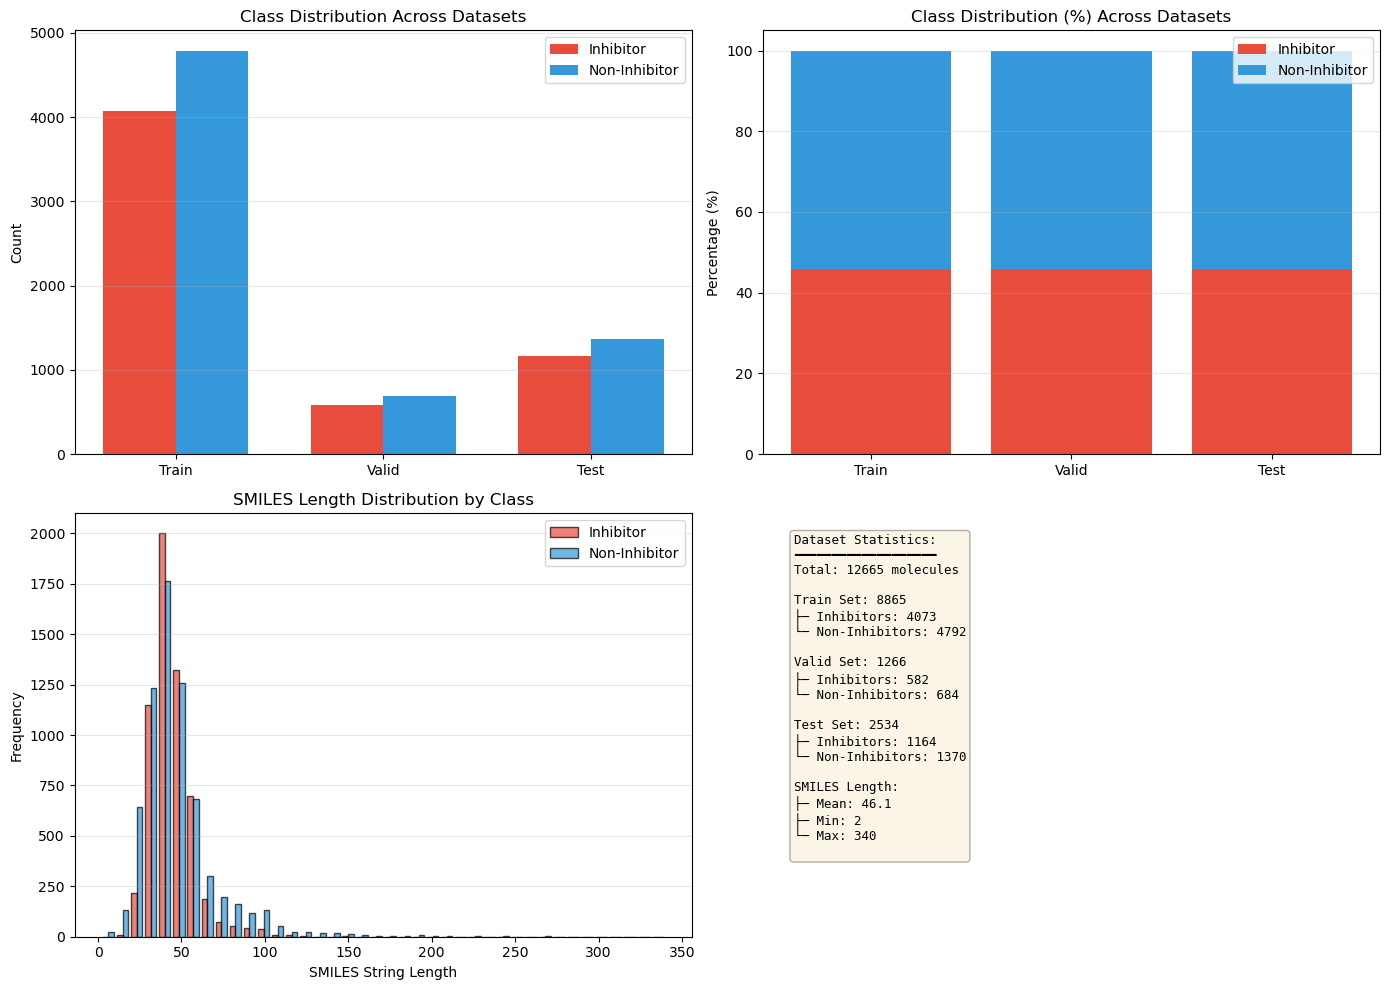

=== EDA Summary ===
Inhibitors: 5819 (45.9%)
Non-Inhibitors: 6846 (54.1%)
SMILES Length - Mean: 46.1, Std: 20.0


In [ ]:
# Class Distribution Analysis
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from rdkit.Chem import Descriptors

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Class distribution across datasets
datasets = ['Train', 'Valid', 'Test']
inhibitor_counts = [
    sum(train_df['Y'] == 1),
    sum(valid_df['Y'] == 1),
    sum(test_df['Y'] == 1)
]
non_inhibitor_counts = [
    sum(train_df['Y'] == 0),
    sum(valid_df['Y'] == 0),
    sum(test_df['Y'] == 0)
]

x = np.arange(len(datasets))
width = 0.35
axes[0, 0].bar(x - width/2, inhibitor_counts, width, label='Inhibitor', color='#e74c3c')
axes[0, 0].bar(x + width/2, non_inhibitor_counts, width, label='Non-Inhibitor', color='#3498db')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Class Distribution Across Datasets')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(datasets)
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Percentage stacked bar
dataset_sizes = [len(train_df), len(valid_df), len(test_df)]
percentages_inhibitor = [c / size * 100 for c, size in zip(inhibitor_counts, dataset_sizes)]
percentages_non = [100 - p for p in percentages_inhibitor]

axes[0, 1].bar(datasets, percentages_inhibitor, label='Inhibitor', color='#e74c3c')
axes[0, 1].bar(datasets, percentages_non, bottom=percentages_inhibitor, 
               label='Non-Inhibitor', color='#3498db')
axes[0, 1].set_ylabel('Percentage (%)')
axes[0, 1].set_title('Class Distribution (%) Across Datasets')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. SMILES length distribution
df_final['smiles_length'] = df_final['Drug'].apply(len)

axes[1, 0].hist([df_final[df_final['Y']==1]['smiles_length'],
                 df_final[df_final['Y']==0]['smiles_length']],
                bins=40, label=['Inhibitor', 'Non-Inhibitor'], 
                color=['#e74c3c', '#3498db'], alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('SMILES String Length')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('SMILES Length Distribution by Class')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3, axis='y')

# 4. Statistics summary
stats_text = f"""Dataset Statistics:
━━━━━━━━━━━━━━━━━━━
Total: {len(df_final)} molecules

Train Set: {len(train_df)}
├─ Inhibitors: {sum(train_df['Y']==1)}
└─ Non-Inhibitors: {sum(train_df['Y']==0)}

Valid Set: {len(valid_df)}
├─ Inhibitors: {sum(valid_df['Y']==1)}
└─ Non-Inhibitors: {sum(valid_df['Y']==0)}

Test Set: {len(test_df)}
├─ Inhibitors: {sum(test_df['Y']==1)}
└─ Non-Inhibitors: {sum(test_df['Y']==0)}

SMILES Length:
├─ Mean: {df_final['smiles_length'].mean():.1f}
├─ Min: {df_final['smiles_length'].min()}
└─ Max: {df_final['smiles_length'].max()}
"""
axes[1, 1].text(0.05, 0.95, stats_text, transform=axes[1, 1].transAxes,
                fontfamily='monospace', fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("=== EDA Summary ===")
print(f"Inhibitors: {sum(df_final['Y']==1)} ({100*sum(df_final['Y']==1)/len(df_final):.1f}%)")
print(f"Non-Inhibitors: {sum(df_final['Y']==0)} ({100*sum(df_final['Y']==0)/len(df_final):.1f}%)")
print(f"SMILES Length - Mean: {df_final['smiles_length'].mean():.1f}, Std: {df_final['smiles_length'].std():.1f}")

Computing molecular descriptors... (this may take a moment)

Molecular Weight:
  Inhibitors - Mean: 367.30, Std: 83.26
  Non-Inhibitors - Mean: 347.72, Std: 122.72

LogP (Lipophilicity):
  Inhibitors - Mean: 3.72, Std: 1.30
  Non-Inhibitors - Mean: 2.31, Std: 2.09

H-Bond Donors:
  Inhibitors - Mean: 0.99, Std: 0.86
  Non-Inhibitors - Mean: 1.44, Std: 1.54

H-Bond Acceptors:
  Inhibitors - Mean: 4.42, Std: 1.70
  Non-Inhibitors - Mean: 4.79, Std: 2.47

Rotatable Bonds:
  Inhibitors - Mean: 4.84, Std: 2.25
  Non-Inhibitors - Mean: 4.26, Std: 2.72

Ring Count:
  Inhibitors - Mean: 3.32, Std: 1.15
  Non-Inhibitors - Mean: 3.03, Std: 1.49


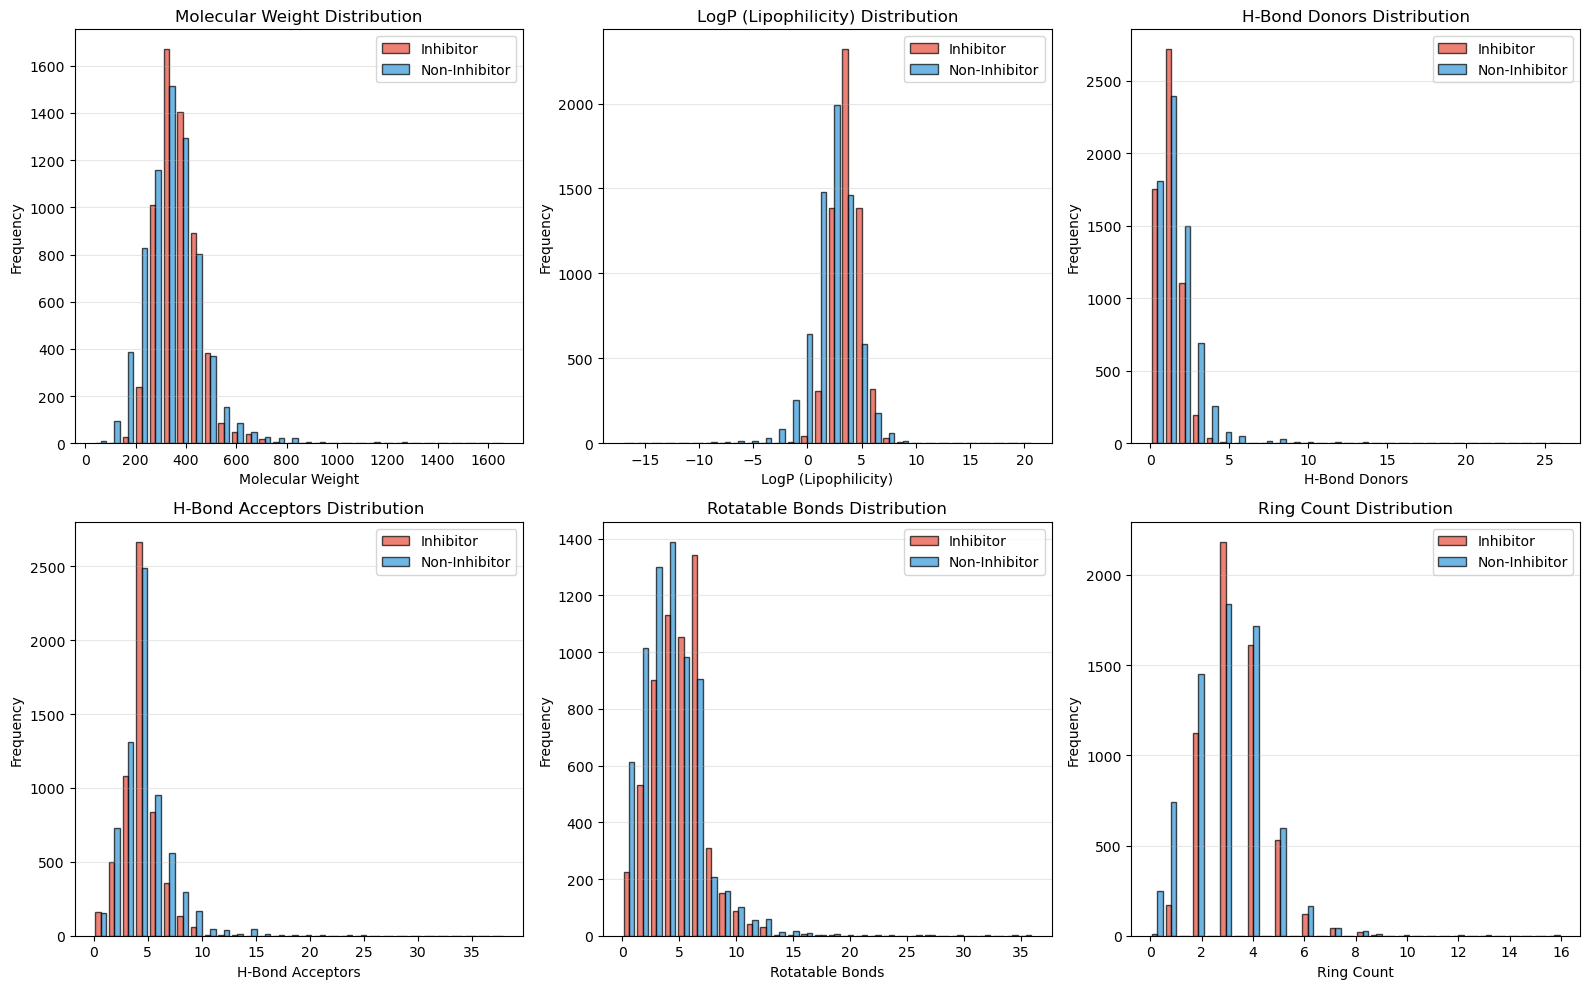

In [ ]:
# Molecular Properties Analysis
import numpy as np

# Compute molecular descriptors
def compute_descriptors(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            return {
                'MW': Descriptors.MolWt(mol),
                'LogP': Descriptors.MolLogP(mol),
                'HBD': Descriptors.NumHDonors(mol),
                'HBA': Descriptors.NumHAcceptors(mol),
                'RotBonds': Descriptors.NumRotatableBonds(mol),
                'Rings': Descriptors.RingCount(mol)
            }
    except:
        pass
    return {k: np.nan for k in ['MW', 'LogP', 'HBD', 'HBA', 'RotBonds', 'Rings']}

print("Computing molecular descriptors... (this may take a moment)")
descriptors_list = df_final['Drug'].apply(compute_descriptors)
descriptors_df = pd.DataFrame(list(descriptors_list))
all_data_with_desc = pd.concat([df_final, descriptors_df], axis=1)

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

properties = ['MW', 'LogP', 'HBD', 'HBA', 'RotBonds', 'Rings']
titles = ['Molecular Weight', 'LogP (Lipophilicity)', 'H-Bond Donors', 
          'H-Bond Acceptors', 'Rotatable Bonds', 'Ring Count']

for idx, (prop, title) in enumerate(zip(properties, titles)):
    inhibitors = all_data_with_desc[all_data_with_desc['Y'] == 1][prop]
    non_inhibitors = all_data_with_desc[all_data_with_desc['Y'] == 0][prop]
    
    axes[idx].hist([inhibitors, non_inhibitors], bins=30, 
                   label=['Inhibitor', 'Non-Inhibitor'],
                   color=['#e74c3c', '#3498db'], alpha=0.7, edgecolor='black')
    axes[idx].set_xlabel(title)
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'{title} Distribution')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3, axis='y')
    
    # Print statistics
    print(f"\n{title}:")
    print(f"  Inhibitors - Mean: {inhibitors.mean():.2f}, Std: {inhibitors.std():.2f}")
    print(f"  Non-Inhibitors - Mean: {non_inhibitors.mean():.2f}, Std: {non_inhibitors.std():.2f}")

plt.tight_layout()
plt.show()


=== Sample CYP2C19 Inhibitors ===


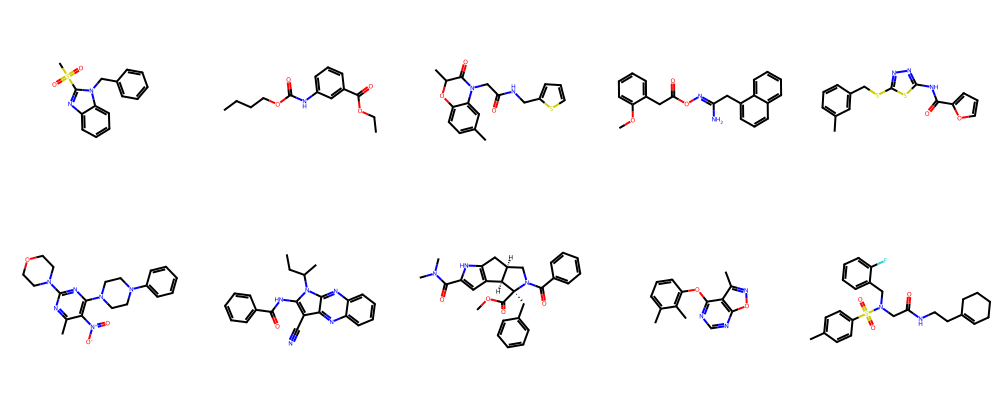


=== Sample Non-Inhibitors ===


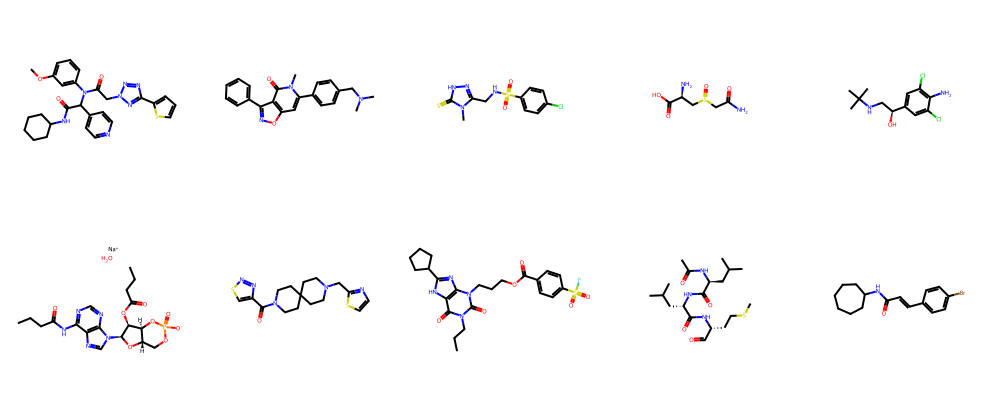

In [ ]:
# Visualize Sample Molecules from Each Class
from IPython.display import display
from rdkit.Chem import Draw

# Get 10 random inhibitors and non-inhibitors
inhibitors_sample = df_final[df_final['Y'] == 1].sample(min(10, sum(df_final['Y']==1)), random_state=42)
non_inhibitors_sample = df_final[df_final['Y'] == 0].sample(min(10, sum(df_final['Y']==0)), random_state=42)

# Parse molecules
inhibitor_mols = []
for smiles in inhibitors_sample['Drug']:
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        inhibitor_mols.append(mol)

non_inhibitor_mols = []
for smiles in non_inhibitors_sample['Drug']:
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        non_inhibitor_mols.append(mol)

# Display
print("=== Sample CYP2C19 Inhibitors ===")
if inhibitor_mols:
    img = Draw.MolsToGridImage(inhibitor_mols, molsPerRow=5, subImgSize=(200, 200))
    display(img)

print("\n=== Sample Non-Inhibitors ===")
if non_inhibitor_mols:
    img = Draw.MolsToGridImage(non_inhibitor_mols, molsPerRow=5, subImgSize=(200, 200))
    display(img)
